# Notebook 05: Discrimination analysis (SQ1)

Research Sub-Question 1: Is cross-population discrimination directionally asymmetric after controlling for source training-set size?

Evaluates AUROC and Specificity at 95% Sensitivity across runs, aggregating across seeds and folds using bootstrap 95% Confidence Intervals (CIs). Displays run-to-run variance directly as an empirical result.

## 1. Setup and Load Saved Predictions

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import metrics as MET
from src import stats as ST
from src import results as RES

for mod in (config, MET, ST, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()


Mounted at /content/drive


In [ ]:
meta, arrays = RES.load_predictions(config.RESULTS_DIR / "predictions")
print(f"Loaded {len(meta)} prediction runs from disk.")
print("\nRun distribution by transfer direction:")
print(meta.groupby("direction").size().to_string())


Loaded 48 prediction runs from disk.

Run distribution by transfer direction:
direction
K2N    18
N2K    30


## 2. Per-Run Spread Analysis (Visualizing Model Instability)

In [ ]:
runs = meta.copy()
runs["auroc"] = [
    MET.auroc(arrays[stem]["y_true"], arrays[stem]["y_prob"])
    for stem in runs["stem"]
]
runs["spec95"] = [
    MET.specificity_at_sensitivity(
        arrays[stem]["y_true"],
        arrays[stem]["y_prob"],
        config.FIXED_SENSITIVITY
    )
    for stem in runs["stem"]
]

print("\n--- AUROC Summary by Direction and Seed ---")
print(runs.groupby(["direction", "seed"])["auroc"].agg(["mean", "min", "max", "count"]).round(3).to_string())

print("\n--- AUROC Summary by Direction and Sample Size ---")
print(runs.groupby(["direction", "size"])["auroc"].agg(["mean", "std", "min", "max", "count"]).round(3).to_string())



--- AUROC Summary by Direction and Seed ---
                 mean    min    max  count
direction seed                            
K2N       42    0.542  0.489  0.627      6
          43    0.576  0.507  0.604      6
          44    0.764  0.720  0.813      6
N2K       42    0.665  0.243  0.858     10
          43    0.642  0.305  0.885     10
          44    0.672  0.547  0.815     10

--- AUROC Summary by Direction and Sample Size ---
                 mean    std    min    max  count
direction size                                   
K2N       50    0.613  0.100  0.507  0.751      6
          100   0.634  0.103  0.498  0.769      6
          190   0.636  0.135  0.489  0.813      6
N2K       190   0.660  0.162  0.243  0.885     30


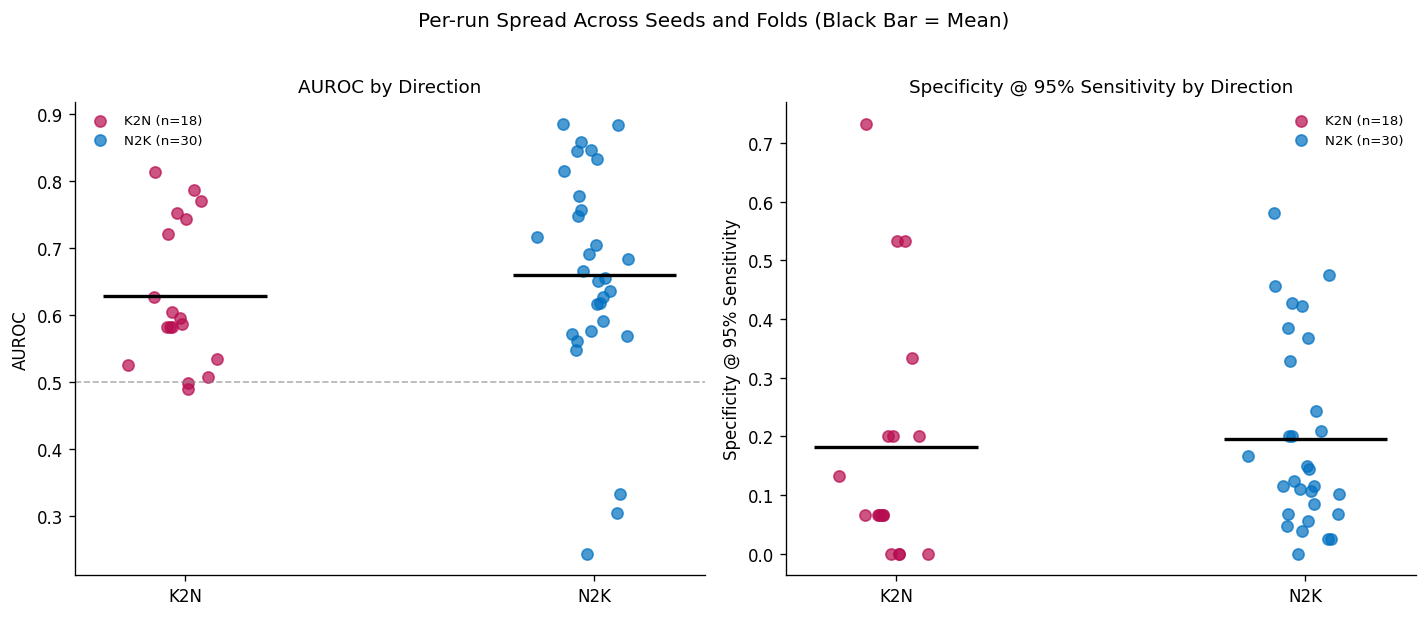

Saved figure to 05_spread_by_direction.png


In [ ]:
# Plot scatter distribution with mean bar overlays
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics_to_plot = [
    (axes[0], "auroc", "AUROC"),
    (axes[1], "spec95", "Specificity @ 95% Sensitivity")
]

for ax, metric, label in metrics_to_plot:
    for i, direction in enumerate(config.DIRECTIONS):
        sub_df = runs[runs.direction == direction]
        x_jitter = np.random.default_rng(0).normal(i, 0.06, len(sub_df))

        ax.scatter(
            x_jitter,
            sub_df[metric],
            alpha=0.7,
            s=45,
            color=[config.BRAND["C1"],
            config.BRAND["C3"]][i],
            label=f"{direction} (n={len(sub_df)})"
        )
        ax.hlines(sub_df[metric].mean(), i - 0.2, i + 0.2, color="black", linewidth=2)

    if metric == "auroc":
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6)

    ax.set_xticks(range(len(config.DIRECTIONS)))
    ax.set_xticklabels(config.DIRECTIONS)
    ax.set_ylabel(label)
    ax.set_title(f"{label} by Direction")
    ax.legend(fontsize=8)

fig.suptitle("Per-run Spread Across Seeds and Folds (Black Bar = Mean)", y=1.02)
fig.tight_layout()

fig_out_path = config.FIGURES_DIR / "05_spread_by_direction.png"
fig.savefig(fig_out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figure to {fig_out_path.name}")


## 3. Pooled Discrimination per Direction with Bootstrap CIs

In [ ]:
rows = []

for direction in config.DIRECTIONS:
    y_true_pooled, y_prob_pooled = RES.pool_predictions(meta, arrays, direction=direction)

    # Bootstrap AUROC
    auroc_pt, auroc_lo, auroc_hi, _ = ST.bootstrap_ci(
        y_true_pooled,
        y_prob_pooled,
        MET.auroc,
        n_boot=config.BOOTSTRAP_N,
        ci=config.BOOTSTRAP_CI,
        seed=config.SEED
    )

    # Bootstrap Specificity at 95% Sensitivity
    spec_func = lambda a, b: MET.specificity_at_sensitivity(a, b, config.FIXED_SENSITIVITY)
    spec_pt, spec_lo, spec_hi, _ = ST.bootstrap_ci(
        y_true_pooled,
        y_prob_pooled,
        spec_func,
        n_boot=config.BOOTSTRAP_N,
        ci=config.BOOTSTRAP_CI,
        seed=config.SEED
    )

    rows.append({
        "direction": direction,
        "n_pooled": len(y_true_pooled),
        "auroc": round(auroc_pt, 3),
        "auroc_lo": round(auroc_lo, 3),
        "auroc_hi": round(auroc_hi, 3),
        "spec95": round(spec_pt, 3),
        "spec95_lo": round(spec_lo, 3),
        "spec95_hi": round(spec_hi, 3)
    })

pooled_df = pd.DataFrame(rows)
print("\n--- Pooled Discrimination by Direction (95% Bootstrap CI) ---")
print(pooled_df.to_string(index=False))

csv_out_path = config.RESULTS_DIR / "05_pooled_discrimination.csv"
pooled_df.to_csv(csv_out_path, index=False)
print(f"Saved summary table to {csv_out_path.name}")



--- Pooled Discrimination by Direction (95% Bootstrap CI) ---
direction  n_pooled  auroc  auroc_lo  auroc_hi  spec95  spec95_lo  spec95_hi
      K2N       540  0.624     0.577     0.670   0.119      0.074      0.167
      N2K     18720  0.662     0.654     0.669   0.153      0.139      0.166
Saved summary table to 05_pooled_discrimination.csv


## 4. Size-Matched Direction Contrast (Size = 190)

The clean matched comparison is at size 190: K2N-190 vs N2K-190. Sizes 50 and 100
feed the size-interaction analysis in notebook 07.

In [ ]:
# Matched comparison controlling for sample size at size = 190
y_true_k2n, y_prob_k2n = RES.pool_predictions(meta, arrays, direction="K2N", size=190)
y_true_n2k, y_prob_n2k = RES.pool_predictions(meta, arrays, direction="N2K")

_, _, _, boot_k2n = ST.bootstrap_ci(
    y_true_k2n,
    y_prob_k2n,
    MET.auroc,
    n_boot=config.BOOTSTRAP_N,
    seed=config.SEED
)
_, _, _, boot_n2k = ST.bootstrap_ci(
    y_true_n2k,
    y_prob_n2k,
    MET.auroc,
    n_boot=config.BOOTSTRAP_N,
    seed=config.SEED
)

diff, diff_lo, diff_hi = ST.bootstrap_diff_ci(boot_n2k, boot_k2n, ci=config.BOOTSTRAP_CI)

k2n_auroc = MET.auroc(y_true_k2n, y_prob_k2n)
n2k_auroc = MET.auroc(y_true_n2k, y_prob_n2k)

print("\n--- Size-Matched Direction Contrast (Size = 190) ---")
print(f"  K2N AUROC: {k2n_auroc:.3f}")
print(f"  N2K AUROC: {n2k_auroc:.3f}")
print(f"  Difference (N2K - K2N): {diff:+.3f}  95% CI [{diff_lo:+.3f}, {diff_hi:+.3f}]")

asymmetry_status = (
    "CI excludes 0: direction contrast is reliable at the 95% level"
    if (diff_lo > 0 or diff_hi < 0)
    else "CI includes 0: no reliable directional asymmetry"
)
print(f"  Conclusion -> {asymmetry_status}")



--- Size-Matched Direction Contrast (Size = 190) ---
  K2N AUROC: 0.638
  N2K AUROC: 0.662
  Difference (N2K - K2N): +0.025  95% CI [-0.055, +0.110]
  Conclusion -> CI includes 0: no reliable directional asymmetry


**Next:** notebook 06 (calibration, SQ2).